# **Разведочный анализ данных (EDA). Линейная регрессия**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Датасэт про страхование жизни:

**age** - возраст человека

**sex** - пол человека

**bmi** - индекс массы тела

**children** - количество детей

**smoker** - курит человек или нет

**region** - район проживания

**charges** - размер страховки


In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/prvshnat/hsedata2425/refs/heads/main/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## Количественные признаки

### Преобразование данных

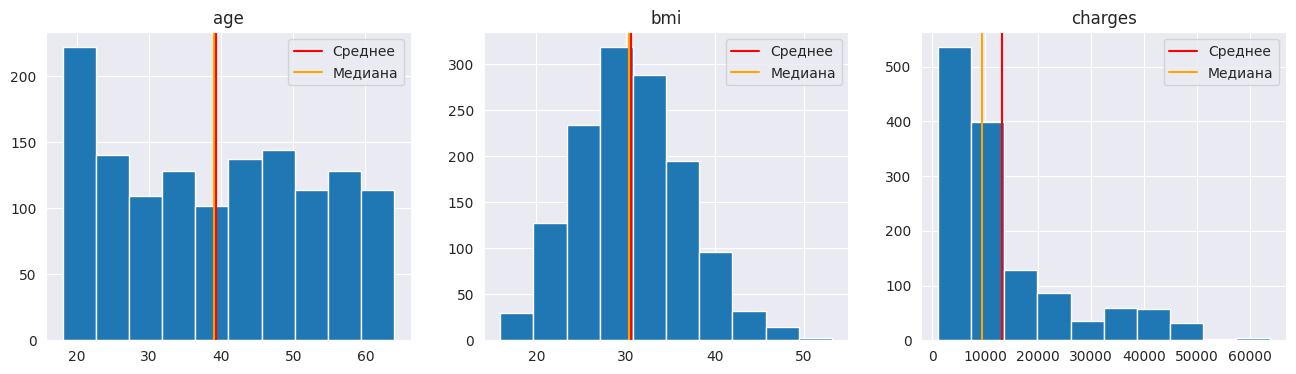

In [ ]:
sns.set_style('darkgrid')
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

lst = ['age', 'bmi', 'charges']

for i in range(len(lst)):
    ax[i].set_title(lst[i])
    ax[i].hist(df[lst[i]]); #df['age']
    ax[i].axvline(df[lst[i]].mean(), color = 'red', label = 'Среднее')
    ax[i].axvline(df[lst[i]].median(), color = 'orange', label = 'Медиана')
    ax[i].legend()

#### **charges**

Признак **charges** имеет сильный скос влево. Давайте попробуем это исправить взявь логорифм от этого признака

In [ ]:
import numpy as np
df['log_charges'] = np.log(df['charges'])
#df['log_charges'] = np.log(df['charges']+1) если бы в данных были нулевые значенич

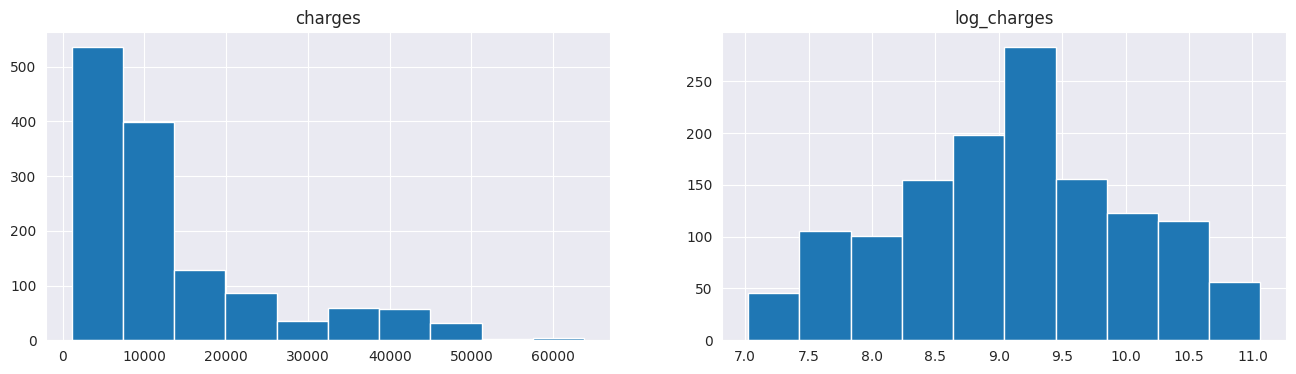

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))

lst = ['charges', 'log_charges']

for i in range(len(lst)):
    ax[i].set_title(lst[i])
    ax[i].hist(df[lst[i]]);

### Выбросы

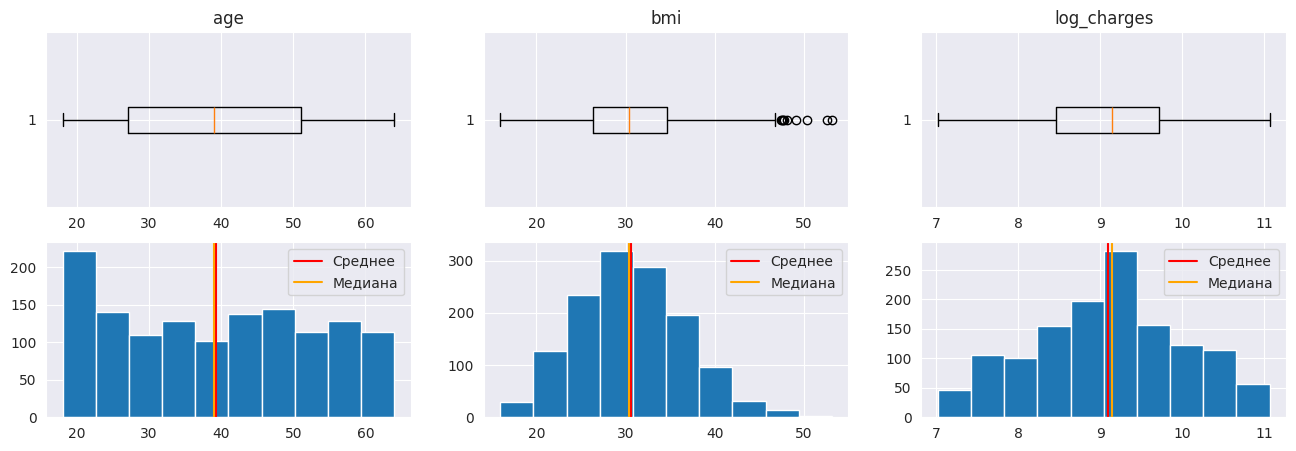

In [ ]:
sns.set_style('darkgrid')
fig, ax = plt.subplots(2, 3, figsize=(16, 5))

lst = ['age', 'bmi', 'log_charges']

for i in range(len(lst)):
    ax[0][i].set_title(lst[i])
    ax[0][i].boxplot(df[lst[i]], vert = False);

    ax[1][i].hist(df[lst[i]]);
    ax[1][i].axvline(df[lst[i]].mean(), color = 'red', label = 'Среднее')
    ax[1][i].axvline(df[lst[i]].median(), color = 'orange', label = 'Медиана')
    ax[1][i].legend()

Находим границы, того что будем считать выбросами

In [ ]:
q1 = df2['bmi'].quantile(0.25)
q3 = df2['bmi'].quantile(0.75)
iqr = q3-q1
left = q1 - 1.5*iqr
right = q3 + 1.5*iqr
left, right

(13.7, 47.290000000000006)

Делаем фильтрацию и оставляем данные без выбросов:

In [ ]:
df_clean = df[(df['bmi']>=left) & (df['bmi']<=right)]
df_clean

,age,sex,bmi,children,smoker,region,charges,log_charges
0,19,female,27.900,0,yes,southwest,16884.92400,9.734176
1,18,male,33.770,1,no,southeast,1725.55230,7.453302
2,28,male,33.000,3,no,southeast,4449.46200,8.400538
3,33,male,22.705,0,no,northwest,21984.47061,9.998092
4,32,male,28.880,0,no,northwest,3866.85520,8.260197
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,9.268661
1334,18,female,31.920,0,no,northeast,2205.98080,7.698927
1335,18,female,36.850,0,no,southeast,1629.83350,7.396233
1336,21,female,25.800,0,no,southwest,2007.94500,7.604867


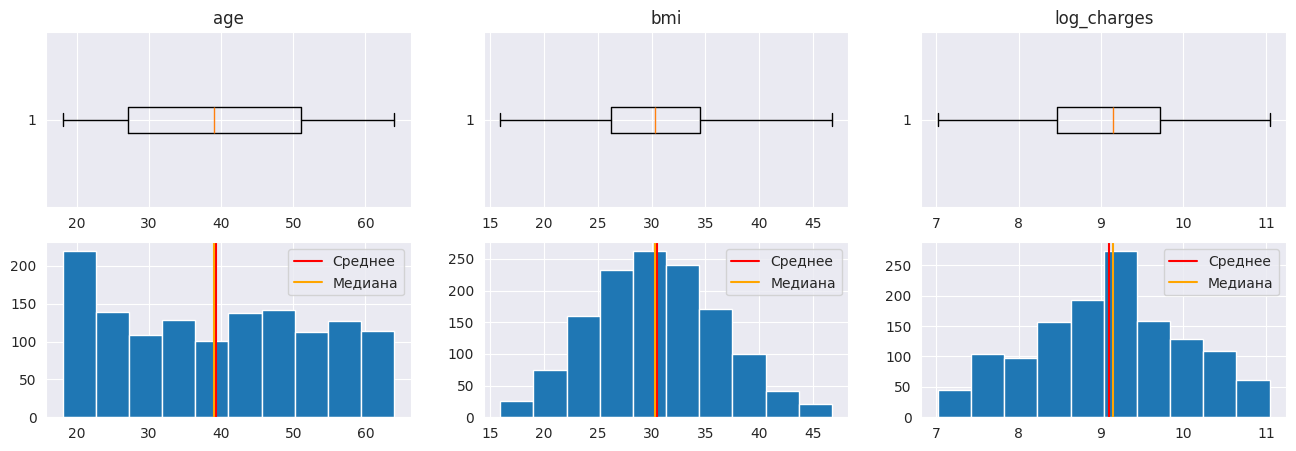

In [ ]:
sns.set_style('darkgrid')
fig, ax = plt.subplots(2, 3, figsize=(16, 5))

lst = ['age', 'bmi', 'log_charges']

for i in range(len(lst)):
    ax[0][i].set_title(lst[i])
    ax[0][i].boxplot(df_clean[lst[i]], vert = False);

    ax[1][i].hist(df_clean[lst[i]]);
    ax[1][i].axvline(df_clean[lst[i]].mean(), color = 'red', label = 'Среднее')
    ax[1][i].axvline(df_clean[lst[i]].median(), color = 'orange', label = 'Медиана')
    ax[1][i].legend()

## Категориальные признаки

In [ ]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges,log_charges
0,19,female,27.900,0,yes,southwest,16884.92400,9.734176
1,18,male,33.770,1,no,southeast,1725.55230,7.453302
2,28,male,33.000,3,no,southeast,4449.46200,8.400538
3,33,male,22.705,0,no,northwest,21984.47061,9.998092
4,32,male,28.880,0,no,northwest,3866.85520,8.260197


In [ ]:
lambda x:  1 if x == 'female' else 0

#### **smoker** и **region**

In [ ]:
df_clean[['sex2', 'region2', 'smoker2']] = df_clean[['sex', 'region', 'smoker']]
df2 = pd.get_dummies(df_clean, columns=['sex2', 'region2', 'smoker2'], dtype = int) #drop_first = True
df2.head()

,age,sex,bmi,children,smoker,region,charges,log_charges,sex2_female,sex2_male,region2_northeast,region2_northwest,region2_southeast,region2_southwest,smoker2_no,smoker2_yes
0,19,female,27.900,0,yes,southwest,16884.92400,9.734176,1,0,0,0,0,1,0,1
1,18,male,33.770,1,no,southeast,1725.55230,7.453302,0,1,0,0,1,0,1,0
2,28,male,33.000,3,no,southeast,4449.46200,8.400538,0,1,0,0,1,0,1,0
3,33,male,22.705,0,no,northwest,21984.47061,9.998092,0,1,0,1,0,0,1,0
4,32,male,28.880,0,no,northwest,3866.85520,8.260197,0,1,0,1,0,0,1,0


In [ ]:
#удалим лишние столбцы
df2.drop(['sex2_male', 'smoker2_no'], axis = 1, inplace = True)

## EDA

Мы хотим построить модель, которая будет предсказывать размер страховой премии, поэтому давайте посмотрим, на зависимости признаков от **log_charges**

### **age** и **bmi**

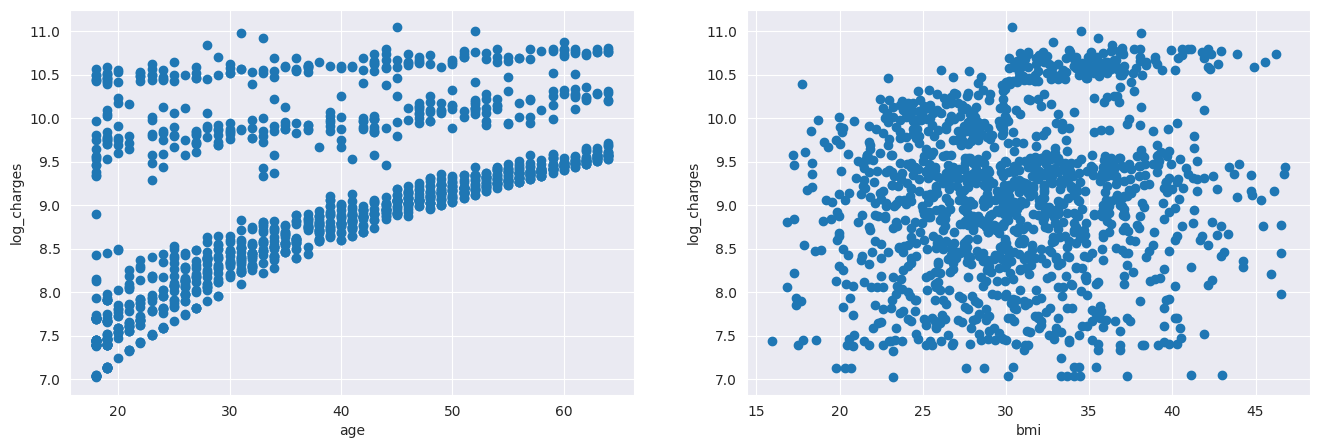

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

lst = ['age', 'bmi']

for i in range(len(lst)):
    ax[i].scatter(df2[lst[i]], df2['log_charges'])
    ax[i].set_ylabel('log_charges')
    ax[i].set_xlabel(lst[i])

На первом графике мы видим, что существует тенденция увеличения расходов с возрастом. Также видны три группы/линии.

На втором графике явных трендов нет.

### **children, sex, smoker, region**

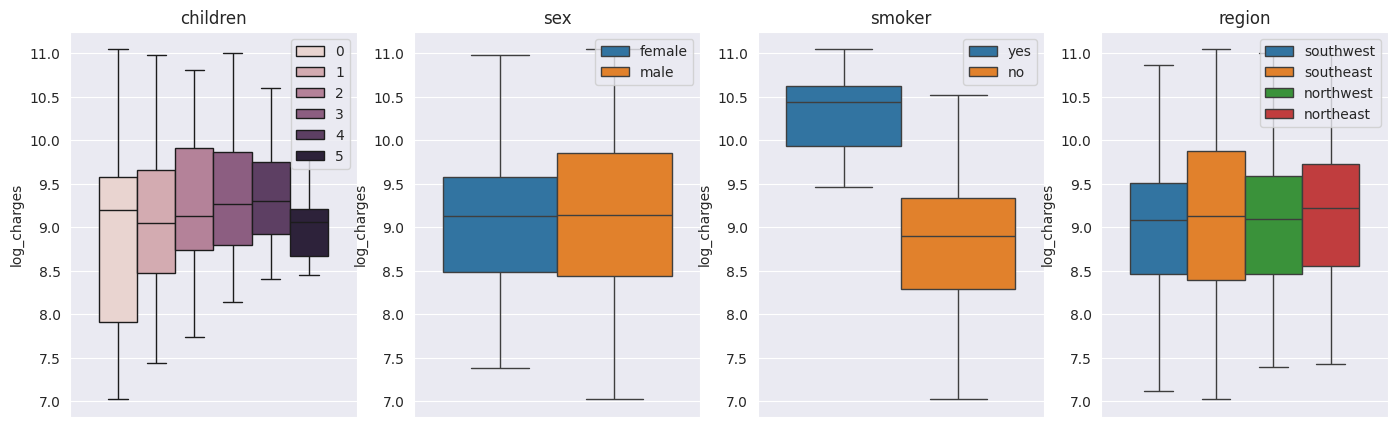

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(17, 5))

lst = ['children', 'sex', 'smoker', 'region']

for i in range(len(lst)):
  ax[i].set_title(lst[i])
  sns.boxplot(y = 'log_charges', data = df2, hue = lst[i], ax = ax[i])
  ax[i].legend(loc=1)

1. Люди с большим количеством детей платят более высокие страховые сборы
2. Женщины и мужчины платят одинаково за страховку
3. Курильщики платят более больше по сравнению с некурящими
4. Район проживания в целом не оказывает влияние на размер страховки

## Корреляционный анализ

In [ ]:
df_clean['log_charges'].corr(df_clean['age'])

0.5293226340392012

In [ ]:
df_clean['log_charges'].corr(df_clean['bmi'])

0.13391230229300968

Корреляционная матрица:

In [ ]:
df_clean[['age', 'bmi', 'log_charges']].corr()

,age,bmi,log_charges
age,1.000000,0.114686,0.529323
bmi,0.114686,1.000000,0.133912
log_charges,0.529323,0.133912,1.000000


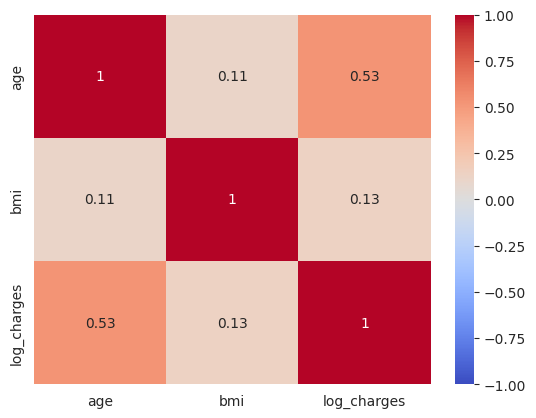

In [ ]:
sns.heatmap(df_clean[['age', 'bmi', 'log_charges']].corr(),
            annot = True,
            vmin = -1,
            vmax = 1,
            cmap="coolwarm");

## Линейная регрессия

### **Статистический подход. Библиотека `statsmodels`**

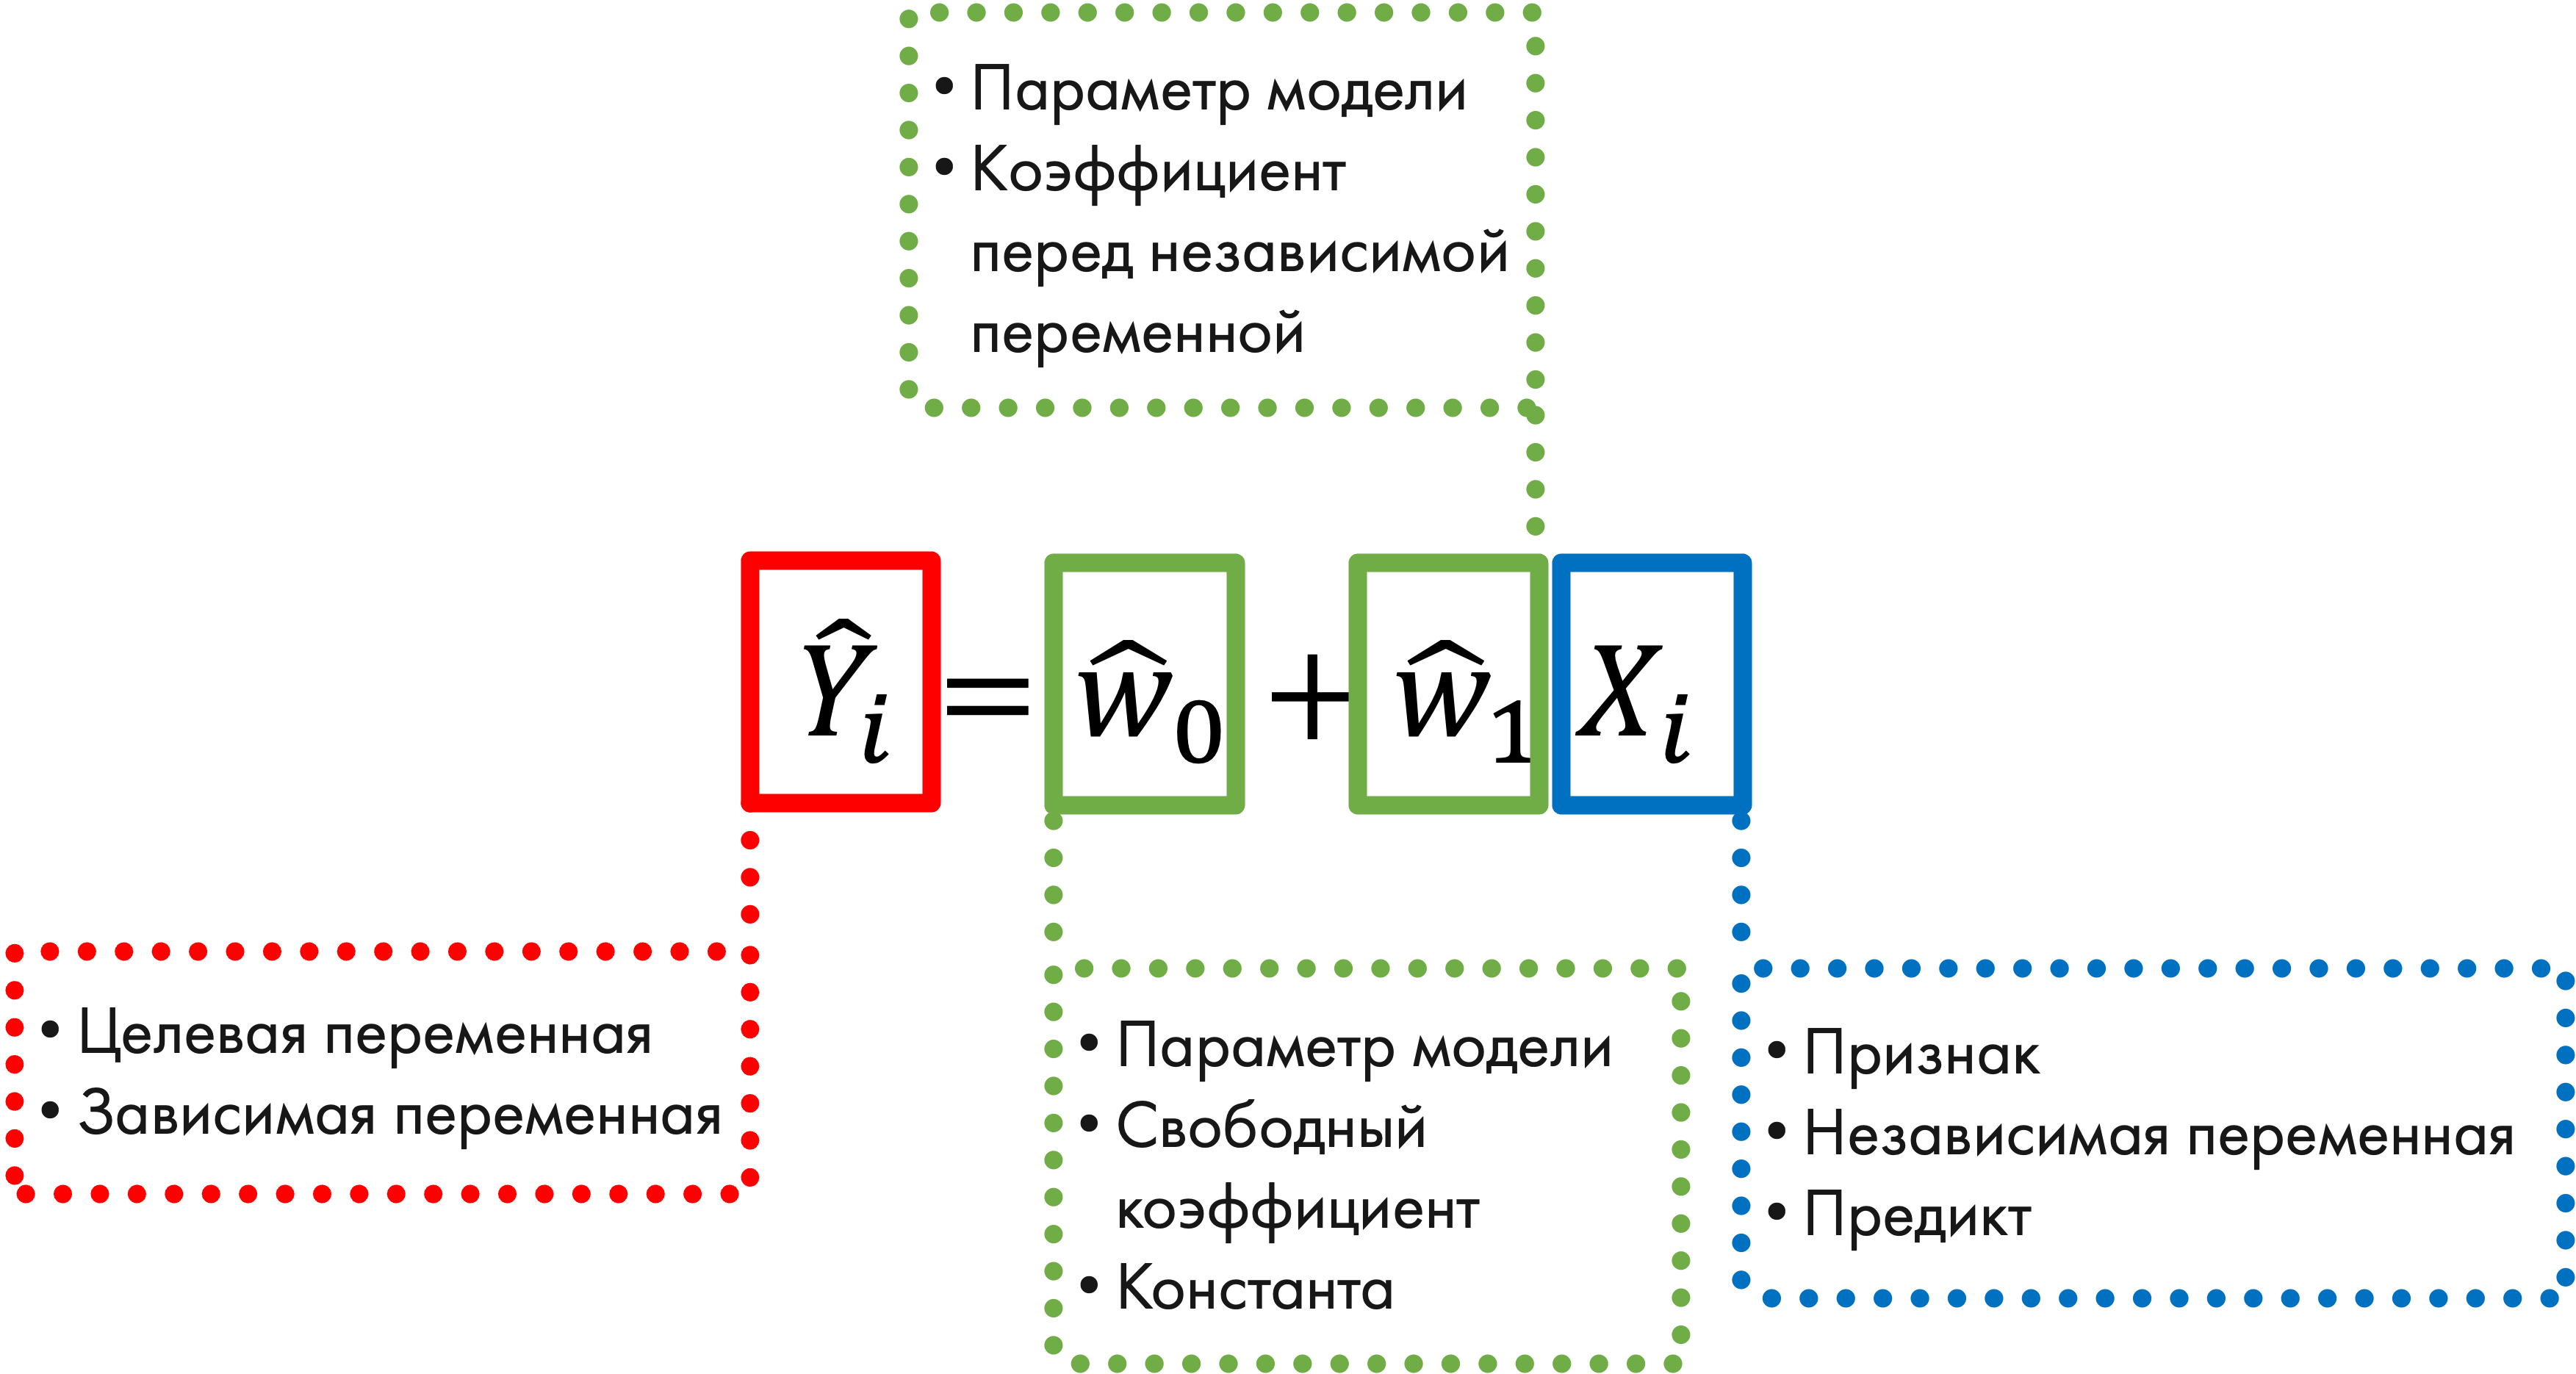

### **Однофакторная регрессия**

Мы хотим построить модель, которая будет показывать как возраст (**age**) влияет на размер страховки (**logcharges**):

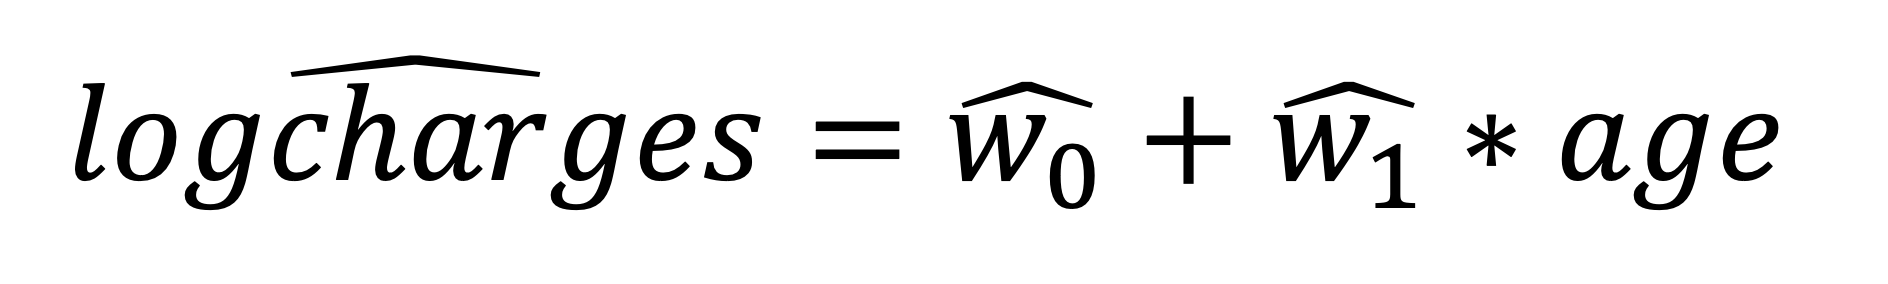

### Обучение модели

Метод наименьших квадратов:

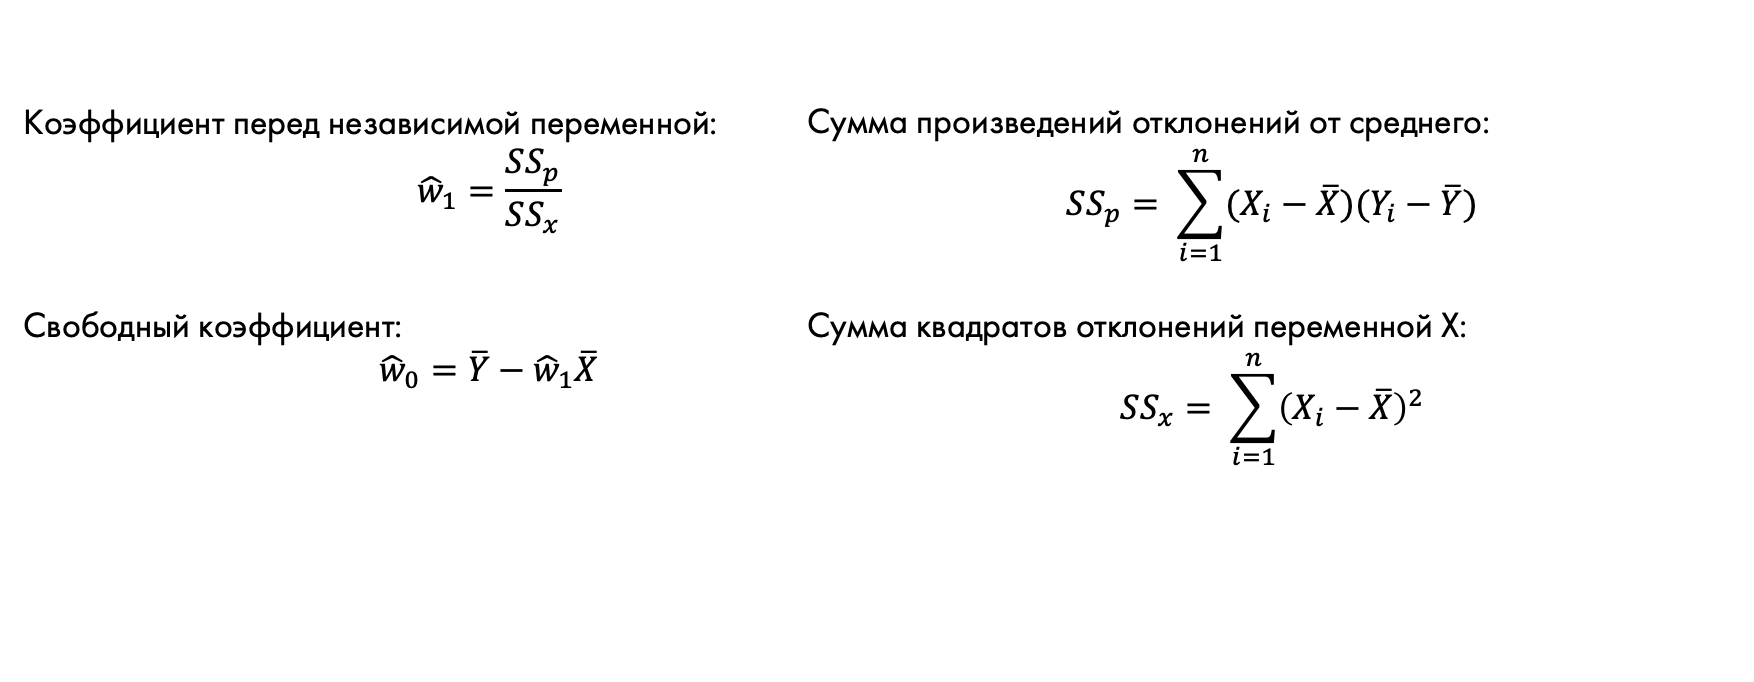

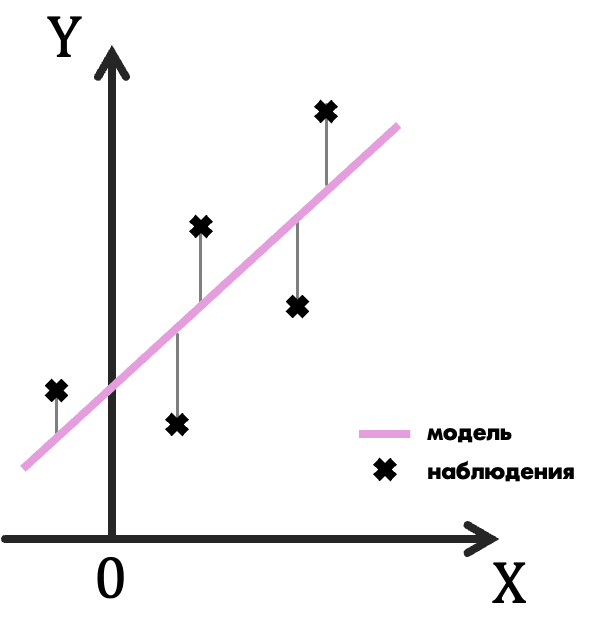

Обучаем модель с помощью библиотеки **statsmodels**:

In [ ]:
import statsmodels.api as sm

X = sm.add_constant(df2["age"]) ## независимая переменная
y = df2["log_charges"] ## целевая переменная

model1 = sm.OLS(y, X).fit() # обучаем модель

### Метрики качества регрессии

#### **Коэфициент детерминации ($R^2$)**

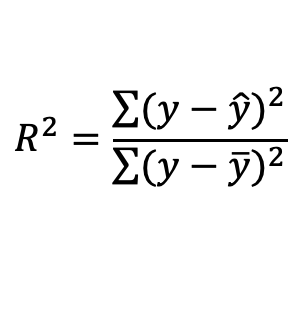

Чем ближе коэффициент детерминации к 1, тем модель лучше. Коэффициент детерминации показывает долю данных, которые описывает модель

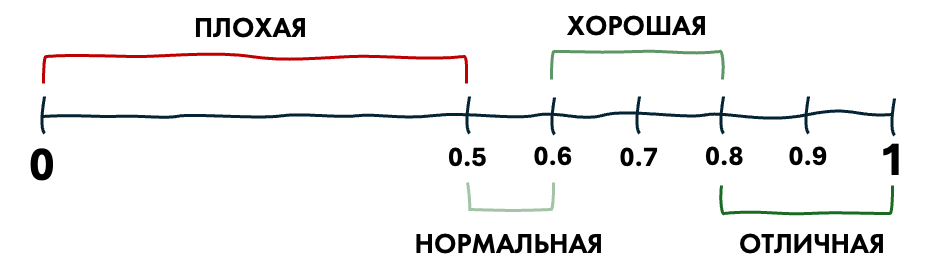

In [ ]:
model1.rsquared

0.2801824509061982

#### **Значимость регрессии (F-statistic)**

Также нужно проверить, что регрессия статистически значима, то есть обеспечивает ли регрессионная модель лучшее соответствие данным, чем модель, которая не содержит независимых переменных.

Если F статистика меньше 0.05, можно говорить, что регрессия значима

In [ ]:
model1.f_pvalue

7.637468516259276e-97

#### **Среднеквадратичная ошибка (MSE)** и **среднеабсолютная ошибка (MAE)**

Показывают ошибку модели:

- Меняются от 0 до +∞
- Чем ближе к 0, тем лучше
- Та модель лучше, у которой MSE или MAE меньше
- МSE одной модели, можно сравнивать только MSE другой
- МAE одной модели, можно сравнивать только MAE другой


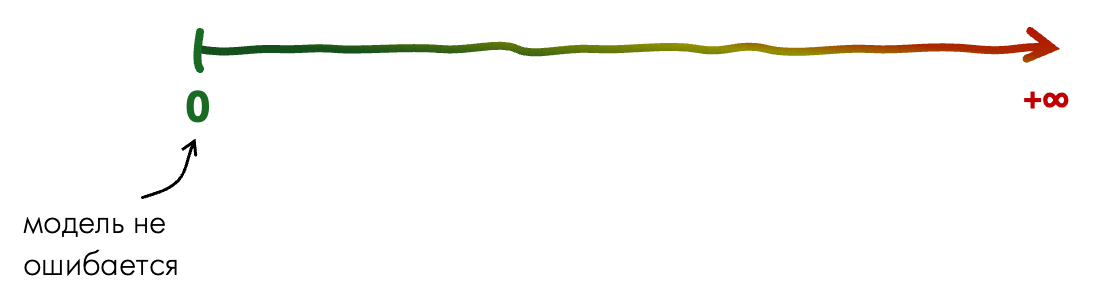

**Среднеквадратичная ошибка**:

$$ MSE = \frac{\Sigma(Y-\widehat{Y})^2}{n} $$

$\Sigma$ - знак суммы, другими словами $(Y_0 - \widehat{Y_0}) + (Y_1 - \widehat{Y_1}) + ... + (Y_n - \widehat{Y_n})$

$Y$ - фактические значения целевой переменной

$\widehat{Y}$ - предсказанные значения целевой переменной `модель.predict(предиктор/ы)`

$n$ - количество наблюдений

In [ ]:
Y_pr = model1.predict(X)
MSE = sum((y-Y_pr)**2)/len(y)
MSE

0.6041370777620427

Модель ошибается, нужно сравнить MSE c другими модели, чтобы выбрать лучшую

**Среднеабсолютная ошибка**:

$$ MAE = \frac{\Sigma |Y-\widehat{Y}| }{n} $$

$\Sigma$ - знак суммы, другими словами $(Y_0 - \widehat{Y_0}) + (Y_1 - \widehat{Y_1}) + ... + (Y_n - \widehat{Y_n})$

$Y$ - фактические значения целевой переменной

$\widehat{Y}$ - предсказанные значения целевой переменной `модель.predict(предиктор/ы)`

$n$ - количество наблюдений

In [ ]:
Y_pr = model1.predict(X)
MAE = sum(abs(y-Y_pr))/len(y)
MAE

0.6274438102981165

#### А14

Выберите верное утверждение о метриках качества, применяемых к модели линейной регрессии без константного признака, обучаемой при помощи минимизации MSE (среднеквадратичной ошибки).

+ MSE и MAE на тестовой выборке для этой модели совпадают.


+ Для оценки качества этой модели на тестовой выборке можно использовать как MSE, так и MAE.


+ При добавлении нового признака в такую модель MSE на тестовой выборке обязательно уменьшится.


+ Оценки коэффициентов в такой модели невозможно корректно интерпретировать.

### Коэффициенты регрессии

#### **Значимость коэффициентов регрессии (P>|t|)**

+ Если значение p-value > 0.1, значит коэффициент статистически незначимый
+ Если значение p-value < 0.1, значит коэффициент значимый на уровне значимости 10%
+ Если значение p-value < 0.05, значит коэффициент значимый на уровне значимости 5%
+ Если значение p-value < 0.01, значит коэффициент значимый на уровне значимости 1%

Чем ближе к 0, тем лучше

In [ ]:
model1.pvalues

,0
const,0.000000e+00
age,7.637469e-97


**Интерпретация коэффициентов регрессии (coef)**

$$ Y = w_0 + w_1×X_1 - w_2×X_2 + w_3×ln(X_3) - w_4×ln(X_4) $$

- $𝑤_0$ - если все предикты равны 0, то $Y$ равен $𝑤_0$

Если $X_1$ и $X_2$ количественные:

- $𝑤_1$ - при увеличении $X_1$ на 1 $Y$ увеличится на $𝑤_1$
- $𝑤_2$ - при увеличении $X_2$ на 1 $Y$ снизится на $𝑤_2$

Если $X_1$ и $X_2$ бинарные(1/0):

- $𝑤_1$ - если $X_1$ равен 1 $Y$ увеличится на $𝑤_1$
- $𝑤_2$ - если $X_2$ равен 1 $Y$ снизится на $𝑤_2$

Если $X_3$ и $X_4$ количественные:

- $𝑤_3$ - при увеличении $X_3$ на 1% $Y$ увеличится на $\frac{𝑤_3}{100}$
- $𝑤_4$ - при увеличении $X_4$ на 1% $Y$ снижается на $\frac{𝑤_4}{100}$

$$ ln(Y) = w_0 + w_1×X_1 - w_2×X_2 + w_3×ln(X_3) - w_4×ln(X_4) $$

- $𝑤_0$ - если все предикты равны 0, то $Y$ равен $e^{𝑤_0}$:
```
import numpy as np
np.exp(w0) #значение Y
```

Если $X_1$ и $X_2$ количественные:
- $𝑤_1$ - при увеличении $X_1$ на 1 $Y$ увеличится на $100*𝑤_1$%
- $𝑤_2$ - при увеличении $X_2$ на 1 $Y$ снизится на $100*𝑤_2$%

Если $X_1$ и $X_2$ бинарные(1/0):
- $𝑤_1$ - если $X_1$ равен 1 $Y$ увеличится на $100*𝑤_1$%
- $𝑤_2$ - если $X_2$ равен 1 $Y$ снизится на $100*𝑤_2$%

Если $X_3$ и $X_4$ количественные:
- $𝑤_3$ - при увеличении $X_3$ на 1% $Y$ увеличится на $𝑤_3$%
- $𝑤_4$ - при увеличении $X_4$ на 1% $Y$ снижается на $𝑤_4$%

$$ ln(\text{charges}) = 7.74 + 0.03*\text{age} $$

In [ ]:
model1.params

,0
const,7.743223
age,0.034533


In [ ]:
ln（ln_charges） = 7.74
ln_charges = e^7.74

In [ ]:
import numpy as np
np.exp(7.74)

2298.472383122332

In [ ]:
ln（ln_charges） = 7.74 +0.03*23
ln(ln_charges) = 8.43


In [ ]:
np.exp(8.43)

4582.500092961236

**w0**
+ Если независимая переменная равна 0, то целевая пременная равна w0

Страховка для младенцев составляет $2298

**w1**
+ При увеличении независимой переменной на единицу целевая переменная увеличивается/уменьшается на 100*w1%

При увеличении возраста на 1 год, страховка увеличивается на 3%

**Регрессия в целом**
+ Если возраст равен N, то страховка будет равна $e^{7.74+0.03*N}$


In [ ]:
import numpy as np
np.exp(7.74)

2298.472383122332

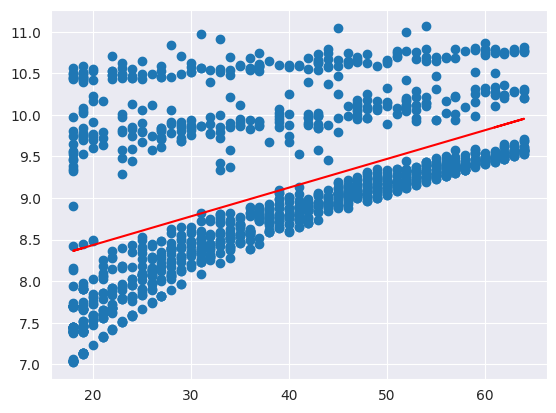

In [ ]:
import matplotlib.pyplot as plt
w0 = model1.params.const
w1 = model1.params.age #0.034533

plt.scatter(df['age'], df['log_charges'])
plt.plot(df['age'], w1*df['age']+w0, color = 'r')

In [ ]:
model1.summary() # выводим регрессионную таблицу

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            log_charges   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.280
Method:                 Least Squares   F-statistic:                     516.5
Date:                Sun, 19 Jan 2025   Prob (F-statistic):           7.64e-97
Time:                        14:52:58   Log-Likelihood:                -1550.9
No. Observations:                1329   AIC:                             3106.
Df Residuals:                    1327   BIC:                             3116.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.7432      0.063    122.375      0.000       7.619       7.867
age            0.0345      0.002     22.727      0.000       0.032       0.038
==============================================================================
Omnibus:                      178.533   Durbin-Watson:                   2.021
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              255.406
Skew:                           1.069   Prob(JB):                     3.46e-56
Kurtosis:                       3.211   Cond. No.                         124.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### А13

Метеоролог Степан хочет оценить зависимость количества осадков (в мм) perc от температуры воздуха (в градусах Цельсия) temp и скорости ветра (в м/с) speed
при помощи линейной модели. Оценённое уравнение регрессии выглядит следующим образом:

$$ perc_𝑖=1−5*temp_𝑖+17.2*speed_𝑖$$

Выберите верное утверждение об интерпретации оценённой модели.

+ При увеличении температуры воздуха на 1 градус Цельсия количество осадков уменьшается на 5 мм.


+ При уменьшении температуры воздуха на 1% количество осадков увеличивается на 5 мм.


+ При увеличении температуры воздуха на 1% градус Цельсия количество осадков уменьшается на 5%.


+ При увеличении скорости ветра на 1 м/с температура воздуха уменьшается на 17.2%.

### Многофакторная регрессия

$$ ln(\text{charges}) = \widehat{w_0} + \widehat{w_1}*\text{age} +\widehat{w_2}*\text{bmi} +\widehat{w_3}*\text{children} + \widehat{w_4}*\text{female} + \widehat{w_5}*\text{smoker} + \widehat{w_6}*\text{northwest} + \widehat{w_7}*\text{southeast} + \widehat{w_8}*\text{southwest}  $$

In [ ]:
import statsmodels.api as sm

X = sm.add_constant(df2[["age", 'bmi', 'children','sex2_female', 'smoker2_yes',
              "region2_northwest",'region2_southeast', 'region2_southwest']]) ## независимые переменные
y = df2["log_charges"] ## целевая переменная


model2 = sm.OLS(y, X).fit() # обучаем модель

Метрики качества регрессии:

In [ ]:
Y_pr = model2.predict(X)
print('R2', model2.rsquared.round(2))
print('MSE', round(sum((y-Y_pr)**2)/len(y), 2))
print('MAE', round(sum(abs(y-Y_pr))/len(y), 2))
print('F-statistic', model2.f_pvalue.round(2))

R2 0.77
MSE 0.2
MAE 0.28
F-statistic 0.0


Значимость коэффициентов регрессии:

In [ ]:
model2.pvalues.round(2)

,0
const,0.00
age,0.00
bmi,0.00
children,0.00
sex2_female,0.00
smoker2_yes,0.00
region2_northwest,0.06
region2_southeast,0.00
region2_southwest,0.00


Коэффициенты регрессии:

$$ ln(\text{charges}) = 6.95 + 0.03*\text{age} +0.01*\text{bmi} +0.1*\text{children} + 0.07*\text{female} + 1.55*\text{smoker} - 0.06*\text{northwest} - 0.16*\text{southeast} - 0.13*\text{southwest}  $$

In [ ]:
model2.params.round(2)

,0
const,6.95
age,0.03
bmi,0.01
children,0.10
sex2_female,0.07
smoker2_yes,1.55
region2_northwest,-0.06
region2_southeast,-0.16
region2_southwest,-0.13


### **Подход машинного обучения**

Делим выборку на обучащую и тестовую:

In [ ]:
from sklearn.model_selection import train_test_split

X = df2[['age', 'bmi', 'children', 'sex2_female', 'smoker2_yes',
                        'region2_northwest', 'region2_southeast', 'region2_southwest']]
Y = df2['log_charges']

(X_train, X_test, y_train, y_test) = train_test_split(X, Y, test_size = .2)

In [ ]:
X_train

,age,bmi,children,sex2_female,smoker2_yes,region2_northwest,region2_southeast,region2_southwest
613,34,19.000,3,True,False,False,False,False
369,18,30.400,3,False,False,False,False,False
367,42,24.985,2,True,False,True,False,False
1160,43,34.580,1,True,False,True,False,False
1334,18,31.920,0,True,False,False,False,False
...,...,...,...,...,...,...,...,...
321,26,29.640,4,True,False,False,False,False
947,37,34.200,1,False,True,False,False,False
497,45,28.700,2,False,False,False,False,True
1161,34,42.130,2,False,False,False,True,False


In [ ]:
y_train

,log_charges
996,8.911735
690,7.651649
1296,7.443620
295,7.441067
1042,10.418579
...,...
358,7.516043
66,9.563464
954,9.903969
194,7.036562


#### Модель 1

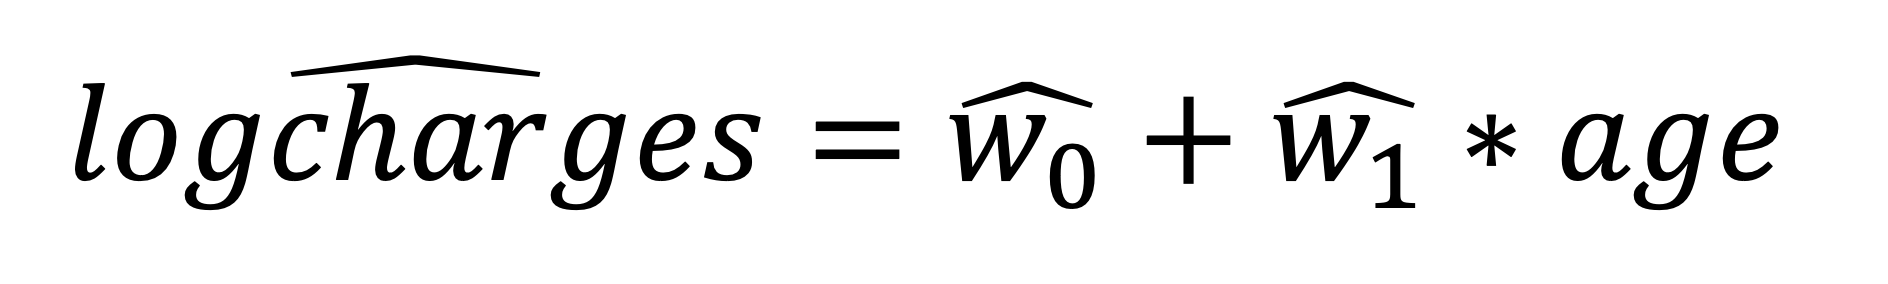

Обучаем модель (на обучающей выборке):

In [ ]:
from sklearn.linear_model import LinearRegression

x_train = X_train[['age']]

lin_model1 = LinearRegression().fit(x_train, y_train)

Считаем метрики качества:

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
x_test = X_test[['age']]
y_test_pred = lin_model1.predict(x_test) #ищем предсказанные значения
print('R2', round(r2_score(y_test, y_test_pred), 2))
print('MSE', round(mean_squared_error(y_test, y_test_pred), 2))

R2 0.24
MSE 0.59


Смотрим на коэффициенты модели:

$$ ln(\text{charges}) = 7.72 + 0.04*\text{age} $$

In [ ]:
lin_model1.coef_ #коэфициент перед независимой переменной

array([0.03508354])

In [ ]:
lin_model1.intercept_.round(2) #свободный коэффициент

7.72

#### Модель 2:

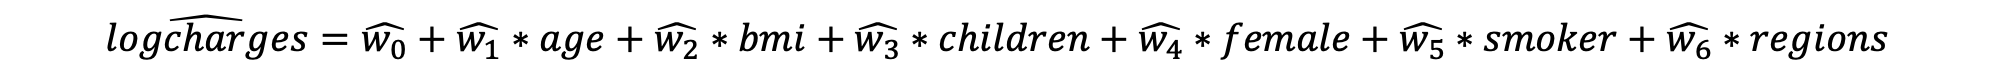

Обучаем модель (на обучающей выборке):

In [ ]:
lin_model2 = LinearRegression()
lin_model2.fit(X_train, y_train)

LinearRegression()

Считаем метрики качества:

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
y_test_pred2 = lin_model2.predict(X_test) #ищем предсказанные значения
print('R2', round(r2_score(y_test, y_test_pred2), 2))
print('MSE', round(mean_squared_error(y_test, y_test_pred2), 2))

R2 0.72
MSE 0.22


Смотрим на коэффициенты модели:

$$ ln(\text{charges}) = 6.91 + 0.04*\text{age} +0.01*\text{bmi} +0.11*\text{children} + 0.07*\text{female} + 1.56*\text{smoker} - 0.05*\text{northwest} - 0.12*\text{southeast} - 0.13*\text{southwest}  $$

In [ ]:
lin_model2.coef_.round(2) #коэфициенты перед независимой переменной

array([ 0.04,  0.01,  0.11,  0.07,  1.56, -0.05, -0.12, -0.13])

In [ ]:
lin_model2.intercept_.round(2) #свободный коэффициент

6.91

#### Сравниваем модели

|  | Модель 1 | Модель 2 |
|----------|----------|----------|
| $$ MSE $$    | 0.59  | 0.21  |
| $$ R^2 $$    | 0.34   | 0.76   |

По двум метрикам качества, вторая модель лучше

### **Кросс-валидация**

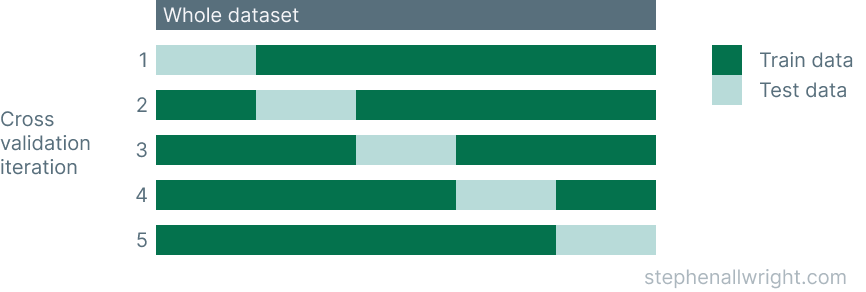

#### Модель 1

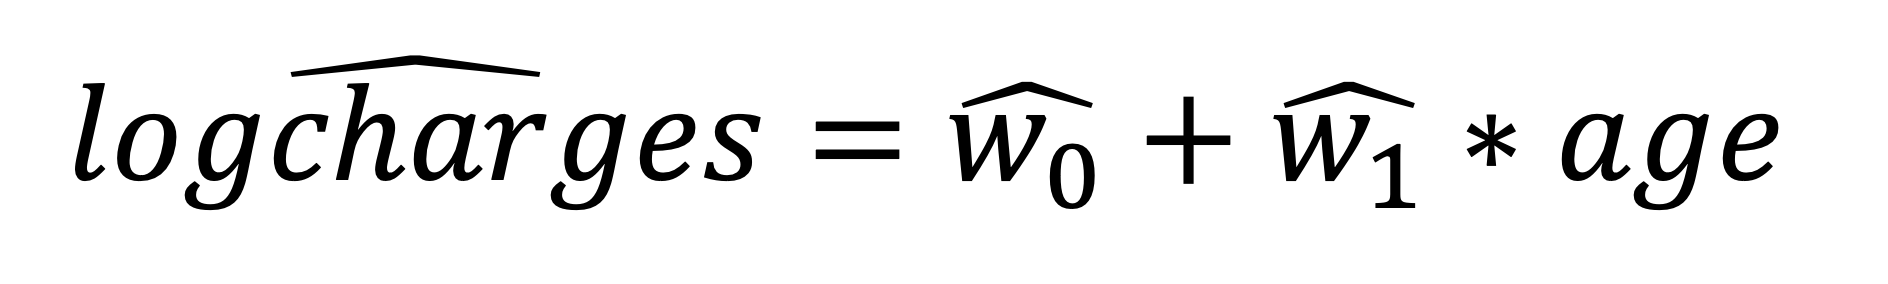

In [ ]:
X1 = df2[['age']]
Y = df2[['log_charges']]

In [ ]:
from sklearn.model_selection import cross_val_score #функция для кросс валидации
from sklearn.linear_model import LinearRegression #функция для линейной регрессии


lin_model = LinearRegression()

scores_MSE = cross_val_score(lin_model, X1, Y, cv=5, scoring='neg_root_mean_squared_error')*-1 #считаем MSE для каждой валидации
scores_R2 = cross_val_score(lin_model, X1, Y, cv=5, scoring='r2') #считаем R2 для каждой валидации
print(f'Среднее значение MSE для Модели 1: {round(scores_MSE.mean(), 2)}')
print(f'Среднее значение R^2 для Модели 1: {round(scores_R2.mean(), 2)}')

Среднее значение MSE для Модели 1: 0.78
Среднее значение R^2 для Модели 1: 0.28


#### Модель 2

In [ ]:
X2 = df2[['age', 'bmi', 'children', 'sex2_female', 'smoker2_yes',
                        'region2_northwest', 'region2_southeast', 'region2_southwest']]
Y = df2['log_charges']

In [ ]:
from sklearn.model_selection import cross_val_score #функция для кросс валидации
from sklearn.linear_model import LinearRegression #функция для линейной регрессии


lin_model = LinearRegression()

scores2_MSE = cross_val_score(lin_model, X2, Y, cv=5, scoring='neg_root_mean_squared_error')*-1 #считаем MSE для каждой валидации
scores2_R2 = cross_val_score(lin_model, X2, Y, cv=5, scoring='r2') #считаем R2 для каждой валидации
print(f'Среднее значение MSE для Модели 1: {round(scores2_MSE.mean(), 2)}')
print(f'Среднее значение R^2 для Модели 1: {round(scores2_R2.mean(), 2)}')

Среднее значение MSE для Модели 1: 0.44
Среднее значение R^2 для Модели 1: 0.76


#### Сравниваем модели

|  | Модель 1 | Модель 2 |
|----------|----------|----------|
| $$ MSE $$    | 0.78  | 0.44  |
| $$ R^2 $$    | 0.28   | 0.76   |

ValueError: Invalid RGBA argument: False

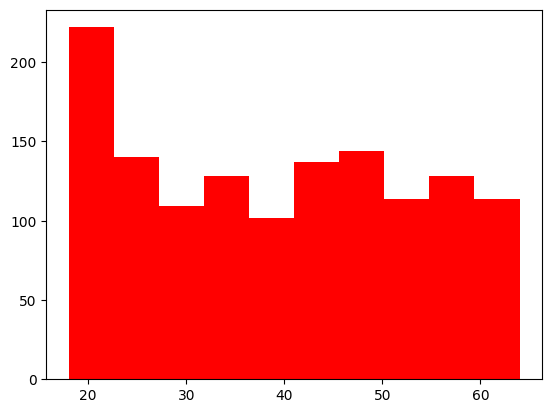

In [ ]:
df['age'].plot(kind = 'hist', color = 'red')